# Decision Tree — Network Intrusion Detection on CIC-IDS 2017

This notebook builds and evaluates a **Decision Tree** classifier for network intrusion detection using the **CIC-IDS 2017** dataset. After training, the model is cross-tested on **CIC-IDS 2018** to assess generalisation ability.

**Overall pipeline:**
1. Load data → Group labels → Preprocess → Feature selection
2. Train Decision Tree → Evaluate on CIC-IDS 2017
3. Cross-dataset evaluation on CIC-IDS 2018 (3 methods)

---

## 1. Import Libraries and Load Data

Import required libraries and load the CIC-IDS 2017 dataset (1 million samples, pre-standardised).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/cicids2017_sample_1M_natural_standardized.csv"
raw_data = pd.read_csv(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label
0,1556494123377,1556494124878,192.168.1.193,59201,192.168.1.33,8080,6,131,288,6,240,6,22,2,20,1501,1500,1500,128,128,48,40,40,48,0,0,144,3,0,0,1533,1278,12,0,0,0,0,8192,0,36864,144,0,0,0,0,0,500,299,244,0,500,299,244,Infiltration
1,1556310687591,1556310687976,192.168.1.32,49246,192.168.1.195,80,6,7,525,6,679,5,27,27,27,385,384,385,64,64,507,40,40,507,1,1,0,0,0,0,10880,14072,9,0,2,0,0,29200,65535,0,0,0,0,0,0,43,257,76,95,0,302,96,120,BruteForce
2,1556030555108,1556030555108,192.168.1.32,64016,192.168.1.152,90,6,0,44,1,40,1,22,2,20,1,0,0,0,0,44,40,40,44,0,0,0,0,0,0,352000,320000,2,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
3,1556035811289,1556035811289,192.168.1.30,27017,192.168.1.46,51635,6,60,48,1,0,0,2,2,0,1,0,0,0,0,48,48,0,48,0,0,0,0,0,0,384000,0,1,0,0,0,0,4096,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
4,1556077316983,1556077316983,192.168.1.79,28201,192.168.1.32,56678,6,0,40,1,0,0,20,20,0,1,0,0,0,0,40,40,0,40,0,0,0,0,0,0,320000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303451,1556050380482,1556050380482,192.168.1.31,48144,192.168.1.49,3306,6,20,44,1,0,0,2,2,0,1,0,0,0,0,44,44,0,44,0,0,0,0,0,0,352000,0,1,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
1303452,1556222979652,1556222979652,192.168.1.184,443,192.168.1.31,49452,6,91,249,1,0,0,24,24,0,1,0,0,0,0,249,249,0,249,0,2,0,0,0,0,1992000,0,0,1,0,0,0,243,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
1303453,1556542694834,1556542694834,192.168.1.1,53,192.168.1.169,51642,17,5,71,1,0,0,0,0,0,1,0,0,0,0,71,71,0,71,0,0,0,0,0,0,568000,0,1,0,0,0,0,0,0,0,0,14697,1,0,0,0,0,0,0,0,0,0,0,Benign
1303454,1556242320575,1556242320575,192.168.1.31,57392,192.168.1.194,80,6,7,112,2,60,1,18,18,18,1,0,0,64,64,60,52,52,60,0,1,0,0,0,0,896000,480000,3,0,0,0,0,29200,5792,0,0,0,0,0,0,0,0,0,0,0,0,0,0,DDoS


## 2. Dataset Summary

Display column names, data types, missing value counts, number of unique values, and a sample value for each column to get a quick overview of the raw dataset.

In [2]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values,
    'Sample Value': [df[col].iloc[0] for col in df.columns]
})
summary

,Column,Data Type,Missing Values,Unique Values,Sample Value
0,FLOW_START_MILLISECONDS,int64,0,1117970,1556494123377
1,FLOW_END_MILLISECONDS,int64,0,1123465,1556494124878
2,IPV4_SRC_ADDR,string[python],0,514,192.168.1.193
3,L4_SRC_PORT,int32,0,53811,59201
4,IPV4_DST_ADDR,string[python],0,1406,192.168.1.33
5,L4_DST_PORT,int32,0,46391,8080
6,PROTOCOL,int8,0,5,6
7,L7_PROTO,int16,0,121,131
8,IN_BYTES,int32,0,5884,288
9,IN_PKTS,int32,0,882,6


## 3. Label Distribution

Visualise the frequency of each attack label to understand class imbalance before applying any grouping or resampling.

Traffic
normal      1107448
DoS           78305
Reconn         8240
CommInj         259
Backdoor        212
Name: count, dtype: int64

% distribution:
Traffic
normal      92.72
DoS          6.56
Reconn       0.69
CommInj      0.02
Backdoor     0.02
Name: count, dtype: float64


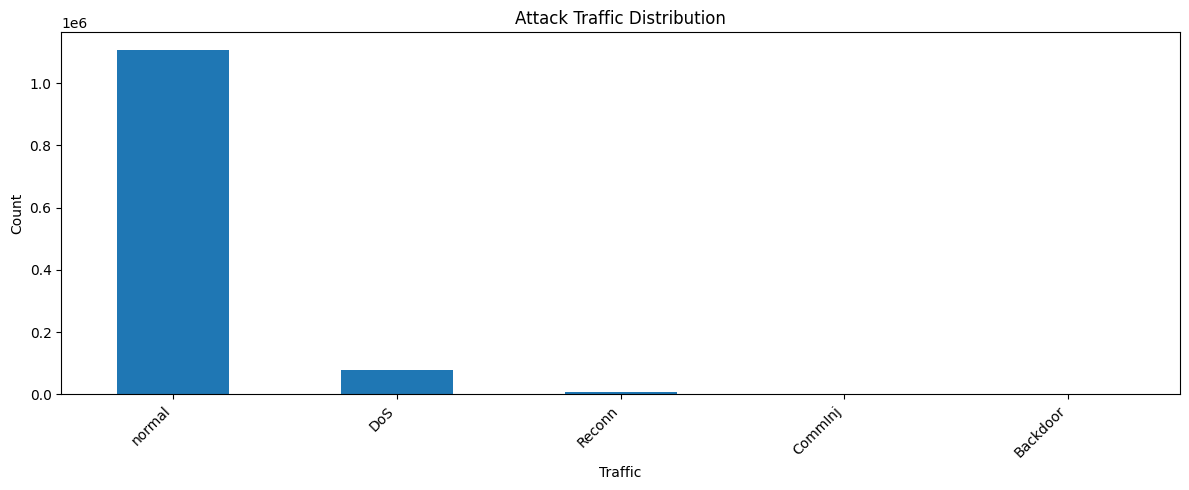

In [ ]:
# ── Label distribution ──────────────────────────────────────────────────────
label_counts = df['Label'].value_counts()
print(label_counts)
print(f"\n% distribution:\n{(label_counts / len(df) * 100).round(2)}")

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## 4. Group Attack Types

Map fine-grained attack labels into five broader categories: **DoS**, **DDoS**, **BruteForce**, **Infiltration**, and **BENIGN**. Rows with unrecognised labels are discarded.

In [4]:
# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'BENIGN': 'BENIGN',

    # DoS / DDoS
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS Slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',

    'DDoS': 'DDoS',

    # Brute Force
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',

    'Web Attack � XSS': 'BruteForce',
    'Web Attack � Brute Force': 'BruteForce',

    'Heartbleed': 'Infiltration',
    'Infiltration': 'Infiltration',
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  BENIGN                  640,639  (74.43%)
  DoS                     138,877  (16.13%)
  DDoS                     72,103  (8.38%)
  BruteForce                9,085  (1.06%)
  Infiltration                 46  (0.01%)


## 5. Check Missing and Infinity Values

Identify columns with missing (`NaN`) or infinite values that must be handled before training the model.

In [5]:
# ── Check missing / infinity values ─────────────────────────────────────────
missing = df.isnull().sum()
print("MISSING VALUES\n", missing[missing > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = {col: np.isinf(df[col]).sum()
              for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("\nINFINITY VALUES")
print(inf_counts if inf_counts else "None")


MISSING VALUES
 Dst Port        36
Flow Byts/s    717
dtype: int64

INFINITY VALUES
{'Flow Byts/s': np.int64(275), 'Flow Pkts/s': np.int64(992)}


## 6. Handle Infinity and Missing Values

Replace `±inf` with `NaN`, then fill any remaining missing values with the column **median** to preserve the overall distribution without introducing bias.

In [6]:
# ── Handle inf → NaN → fill with median ─────────────────────────────────────
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"NaN remaining : {df_processed.isnull().sum().sum()}")
print(f"Shape         : {df_processed.shape}")


/tmp/ipykernel_1350/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_1350/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

NaN remaining : 0
Shape         : (860750, 79)


## 7. Drop Identifier / Metadata Columns

Remove columns that carry no predictive signal and could cause data leakage, such as IP addresses, port numbers, flow IDs, and timestamps.

In [7]:
# ── Drop identifier / metadata columns ──────────────────────────────────────
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns
                if any(k in c.lower() for k in keywords)]

df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Dropped : {cols_to_drop}")
print(f"Shape   : {df_processed.shape}")


Dropped : ['Dst Port']
Shape   : (860750, 78)


## 8. Remove Low-Variance Features

Apply `VarianceThreshold` to drop features whose variance falls below 0.01. Such features carry little discriminating power and only add noise.

In [8]:
# ── Remove low-variance features ─────────────────────────────────────────────
from sklearn.feature_selection import VarianceThreshold

y = df_processed['Label']
X = df_processed.drop('Label', axis=1)

selector = VarianceThreshold(threshold=0.01)
X_hv = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()].tolist()

df_processed = pd.DataFrame(X_hv, columns=selected_features)
df_processed['Label'] = y.values

print(f"Features : {X.shape[1]} → {len(selected_features)} (removed {X.shape[1]-len(selected_features)})")
print(f"Shape    : {df_processed.shape}")


Features : 77 → 65 (removed 12)
Shape    : (860750, 66)


## 9. Remove Outliers via Z-Score

Filter out samples where **any** feature has a Z-score magnitude greater than 3, reducing the influence of extreme values on the model.

In [9]:
# ── Remove outliers via Z-score (threshold = 3) ──────────────────────────────
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import pickle

X_temp = df_processed.drop('Label', axis=1)
y_temp = df_processed['Label']

mask = (np.abs(stats.zscore(X_temp)) < 3).all(axis=1)
df_processed = X_temp[mask].copy()
df_processed['Label'] = y_temp[mask]

print(f"Removed  : {(~mask).sum()} outliers ({(~mask).mean()*100:.2f}%)")



Removed  : 331533 outliers (38.52%)


## 10. Drop Highly Correlated Features

Remove features with a Pearson correlation coefficient > 0.95 (upper triangle) to reduce redundancy and multicollinearity in the feature set.

In [10]:
# ── Drop highly correlated features (r > 0.95) ───────────────────────────────
X_for_corr = df_processed.drop('Label', axis=1)
upper = X_for_corr.corr().abs().where(
    np.triu(np.ones(X_for_corr.shape[1], dtype=bool), k=1))
to_drop = [c for c in upper.columns if upper[c].max() > 0.95]

df_processed.drop(columns=to_drop, inplace=True)
print(f"Dropped  : {len(to_drop)} correlated features")

Dropped  : 31 correlated features


## 11. Label Encoding

Encode string class labels into integer indices using `LabelEncoder`. The fitted encoder is saved to disk for reuse during cross-dataset evaluation.

In [11]:
# ── Label encoding ───────────────────────────────────────────────────────────
le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

with open('label_encoder.pkl1', 'wb') as f:
    pickle.dump(le, f)

print(f"\nShape    : {df_processed.shape}")
for idx, label in enumerate(le.classes_):
    print(f"  {idx}: {label}  ({(df_processed['Label_Encoded']==idx).sum():,} samples)")


Shape    : (529217, 36)
  0: BENIGN  (405,067 samples)
  1: BruteForce  (4,004 samples)
  2: DDoS  (47,187 samples)
  3: DoS  (72,954 samples)
  4: Infiltration  (5 samples)


## 12. Train / Test Split

Split into **80% training** and **20% test** using stratified sampling to preserve class proportions across both partitions.

In [12]:
# ── Train / test split (stratified 80/20) ────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")


Train : (423373, 34)  |  Test : (105844, 34)


## 13. Final Feature Summary

Print the final feature count, class count, and per-class sample distribution for both the training and test partitions.

In [13]:
# ── Final feature summary ─────────────────────────────────────────────────────
print(f"Features : {X_train.shape[1]}  |  Classes : {len(le.classes_)}")
print(f"Train    : {X_train.shape[0]:,} samples")
print(f"Test     : {X_test.shape[0]:,} samples")
for i, c in enumerate(X_train.columns, 1):
    print(f"  {i:3d}. {c}")


Features : 34  |  Classes : 5
Train    : 423,373 samples
Test     : 105,844 samples
    1. Flow Duration
    2. Tot Fwd Pkts
    3. TotLen Fwd Pkts
    4. Fwd Pkt Len Max
    5. Fwd Pkt Len Min
    6. Fwd Pkt Len Mean
    7. Bwd Pkt Len Max
    8. Bwd Pkt Len Min
    9. Flow Byts/s
   10. Flow Pkts/s
   11. Flow IAT Mean
   12. Flow IAT Min
   13. Fwd IAT Min
   14. Bwd IAT Tot
   15. Bwd IAT Mean
   16. Bwd IAT Std
   17. Bwd IAT Max
   18. Bwd IAT Min
   19. Fwd PSH Flags
   20. Bwd Packets/s
   21. FIN Flag Cnt
   22. SYN Flag Cnt
   23. PSH Flag Cnt
   24. ACK Flag Cnt
   25. URG Flag Cnt
   26. Down/Up Ratio
   27. Init Fwd Win Byts
   28. Init Bwd Win Byts
   29. Fwd Act Data Pkts
   30. Fwd Seg Size Min
   31. Active Mean
   32. Active Std
   33. Active Max
   34. Idle Std


---

## 14. Model Training — Decision Tree

Import `DecisionTreeClassifier` and evaluation utilities required for training and analysis.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)
import seaborn as sns


### 14.1 Train the Model

Fit a `DecisionTreeClassifier` with a maximum depth of 20, minimum leaf size of 4, and `class_weight='balanced'` to handle class imbalance.

In [15]:
# ── Train Decision Tree ───────────────────────────────────────────────────────
dt_classifier = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight='balanced'
)
dt_classifier.fit(X_train, y_train)
print(f"Training done — depth: {dt_classifier.get_depth()}  |  leaves: {dt_classifier.get_n_leaves()}")


Training done — depth: 20  |  leaves: 316


### 14.2 Training vs Test Accuracy

Compare training and test accuracy to detect potential overfitting. A gap larger than 5% is flagged as overfitting.

In [16]:
# ── Evaluate on train / test set ──────────────────────────────────────────────
y_train_pred = dt_classifier.predict(X_train)
y_test_pred  = dt_classifier.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Test  accuracy : {test_acc*100:.2f}%")
print(f"Gap            : {(train_acc - test_acc)*100:.2f}%  {'(overfitting)' if train_acc-test_acc>0.05 else '(OK)'}")


Train accuracy : 99.94%
Test  accuracy : 99.92%
Gap            : 0.02%  (OK)


### 14.3 Classification Report

Per-class **precision**, **recall**, **F1-score**, and **support** on the test set.

In [17]:
# ── Classification report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.9998    0.9992    0.9995     81014
  BruteForce     0.9938    0.9925    0.9931       801
        DDoS     0.9985    0.9997    0.9991      9437
         DoS     0.9969    0.9995    0.9982     14591
Infiltration     0.0000    0.0000    0.0000         1

    accuracy                         0.9992    105844
   macro avg     0.7978    0.7982    0.7980    105844
weighted avg     0.9992    0.9992    0.9992    105844



### 14.4 Confusion Matrix

Visualise prediction errors using both raw **counts** and **normalised percentages** side-by-side.

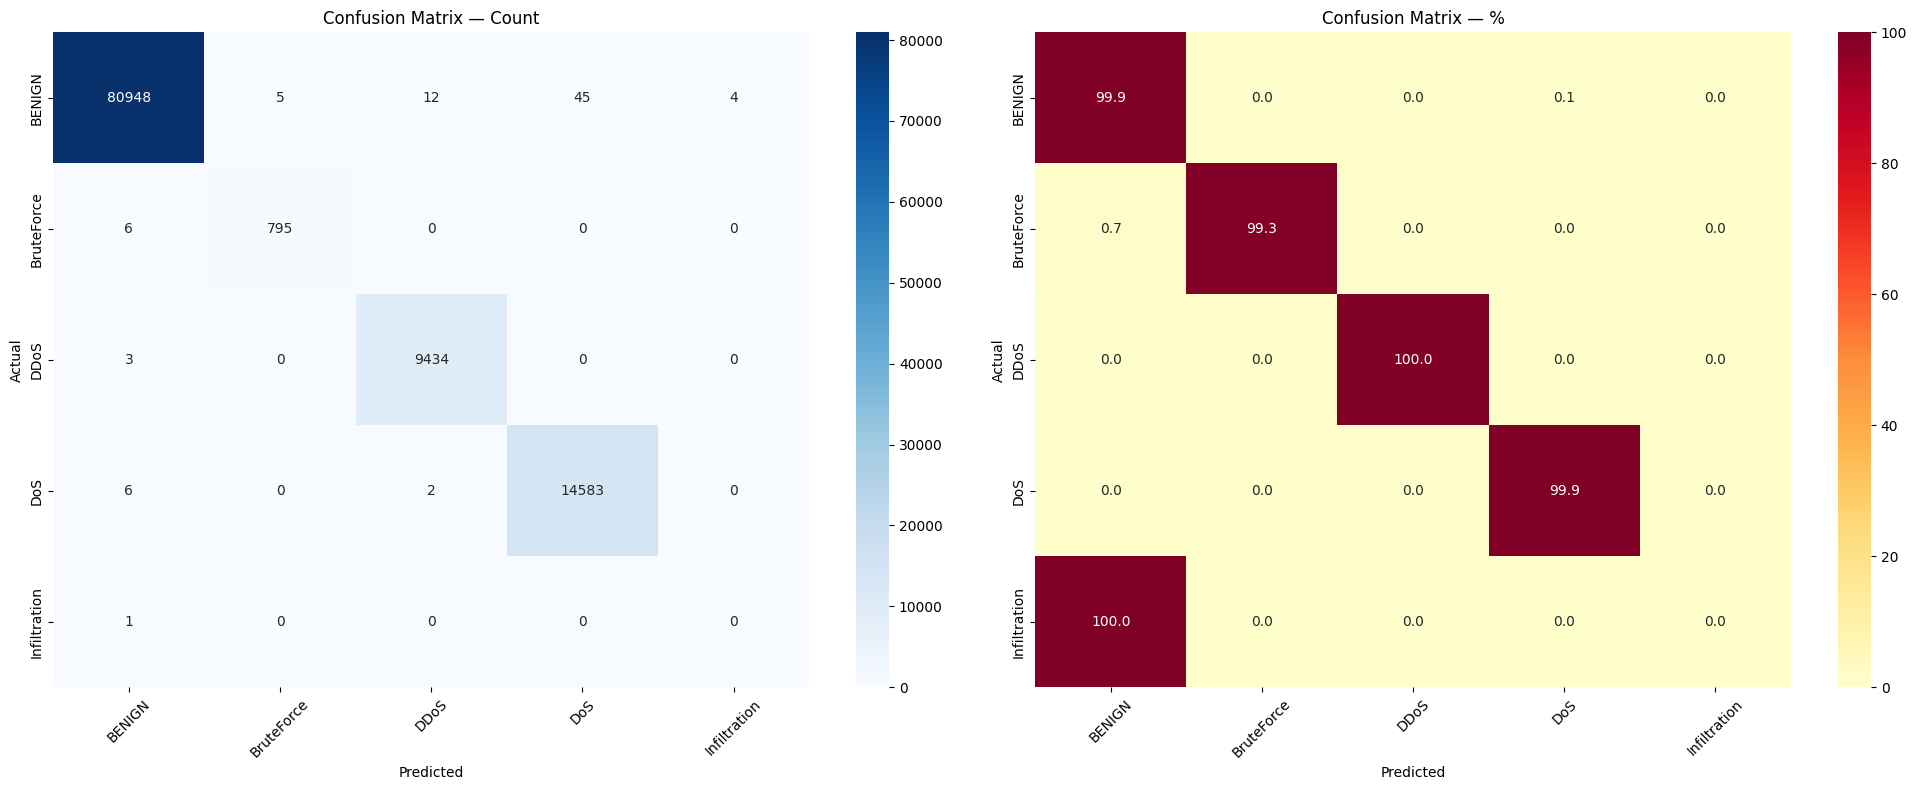

In [18]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Confusion Matrix — Count')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('Confusion Matrix — %')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---

## 15. Cross-Dataset Evaluation on CIC-IDS 2018

Load the CIC-IDS 2018 dataset (balanced, pre-standardised) to evaluate how well the model trained on 2017 data generalises to a different year.

In [19]:
# ── Load CIC-IDS 2018 dataset ────────────────────────────────────────────────
CIC18_PATH = "../../../../dataset/cic2018_balanced_dataset_standardized.parquet"
df18_raw = pd.read_parquet(CIC18_PATH)
print(f"Shape : {df18_raw.shape}")
print(df18_raw['Label'].value_counts())

Shape : (263647, 81)
Label
Benign                      49999
DDOS attack-HOIC            25000
DDoS attacks-LOIC-HTTP      25000
DoS attacks-Hulk            25000
DoS attacks-SlowHTTPTest    25000
DoS attacks-GoldenEye       25000
SSH-Bruteforce              25000
FTP-BruteForce              25000
Infilteration               25000
DoS attacks-Slowloris       10990
DDOS attack-LOIC-UDP         1730
Brute Force -Web              611
Brute Force -XSS              230
SQL Injection                  87
Name: count, dtype: Int64


### 15.1 Group Attack Types (CIC-IDS 2018)

Apply the same attack-type grouping scheme to the 2018 labels so they align with the classes seen during training.

In [20]:
# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping_18 = {
    # # BENIGN
    'Benign': 'BENIGN',

    # DoS / DDoS
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-Slowhttptest': 'DoS',

    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDoS attacks-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',

    # Brute Force
    'FTP-BruteForce': 'BruteForce',
    'SSH-Bruteforce': 'BruteForce',

    'Brute Force -Web': 'BruteForce',
    'Brute Force -XSS': 'BruteForce',

    'Infilteration': 'Infiltration',
    # 'Bot': 'Bot',
}

df18 = df18_raw.copy()
df18['Label'] = df18['Label'].map(attack_group_mapping_18)
df18.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df18['Label'].nunique()}")
for g, cnt in df18['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df18)*100:.2f}%)")


Groups after mapping : 5
  DoS                      60,990  (25.75%)
  BruteForce               50,841  (21.47%)
  DDoS                     50,000  (21.11%)
  BENIGN                   49,999  (21.11%)
  Infiltration             25,000  (10.56%)


### 15.2 Preprocess CIC-IDS 2018

Apply the same preprocessing pipeline (inf/NaN handling, metadata column removal) to the 2018 dataset and identify the shared feature set between 2017 and 2018.

In [21]:
# Preprocess CIC-2018 with the same pipeline as training data
df18_proc = df18.copy()
df18_proc.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df18_proc.select_dtypes(include=[np.number]).columns:
    if df18_proc[col].isnull().sum() > 0:
        df18_proc[col].fillna(df18_proc[col].median(), inplace=True)

keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
df18_proc.drop(columns=[c for c in df18_proc.columns if any(k in c.lower() for k in keywords)],
               inplace=True, errors='ignore')

train_features = X_train.columns.tolist()
shared_features = [f for f in train_features if f in df18_proc.columns]
missing_in_18 = [f for f in train_features if f not in df18_proc.columns]

print(f"Shape: {df18_proc.shape}  |  Shared: {len(shared_features)}/{len(train_features)}  |  Missing: {len(missing_in_18)}")


Shape: (236830, 79)  |  Shared: 34/34  |  Missing: 0


/tmp/ipykernel_1350/159834823.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df18_proc[col].fillna(df18_proc[col].median(), inplace=True)
/tmp/ipykernel_1350/159834823.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

### 15.3 Method 1 — Direct Cross-Test (Shared Features, No Scaler)

Evaluate the model on the 2018 test set using only features present in both datasets. If any training features are missing in 2018, a new model is retrained on the shared feature subset.

In [22]:
# Method 1: Cross-test on CIC-2018 using shared features (no retrain)
X18 = df18_proc[shared_features]
y18_labels = df18_proc['Label']

mask_known = y18_labels.isin(set(le.classes_))
X18, y18_labels = X18[mask_known], y18_labels[mask_known]
y18 = le.transform(y18_labels)

if missing_in_18:
    DT_Shared = DecisionTreeClassifier(max_depth=20, min_samples_split=10,
                                       min_samples_leaf=4, random_state=42, class_weight='balanced')
    DT_Shared.fit(X_train[shared_features], y_train)
    acc18_shared = accuracy_score(y_test, DT_Shared.predict(X_test[shared_features]))
    y18_pred = DT_Shared.predict(X18)
    print(f"2018 test (all feats): {test_acc*100:.2f}%  |  2018 test (shared feats): {acc18_shared*100:.2f}%")
else:
    y18_pred = dt_classifier.predict(X18)

acc18_cross = accuracy_score(y18, y18_pred)
print(f"2018 test accuracy : {test_acc*100:.2f}%")
print(f"2018 cross accuracy: {acc18_cross*100:.2f}%")
print(f"Cross-dataset drop : {(test_acc - acc18_cross)*100:.2f}%\n")

present_indices = sorted(set(y18))
print(classification_report(y18, y18_pred, labels=present_indices,
                             target_names=le.inverse_transform(present_indices),
                             digits=4, zero_division=0))


2018 test accuracy : 99.92%
2018 cross accuracy: 32.62%
Cross-dataset drop : 67.30%

              precision    recall  f1-score   support

      BENIGN     0.2389    0.9962    0.3853     49999
  BruteForce     0.0000    0.0000    0.0000     50841
        DDoS     0.9989    0.1613    0.2777     50000
         DoS     0.9876    0.3175    0.4805     60990
Infiltration     0.5200    0.0005    0.0010     25000

    accuracy                         0.3262    236830
   macro avg     0.5491    0.2951    0.2289    236830
weighted avg     0.5705    0.3262    0.2638    236830



### 15.4 Method 2 — Cross-Test with StandardScaler

Rescale training and 2018 features with `StandardScaler` and compare accuracy with and without scaling to measure the impact of normalisation on cross-dataset performance.

In [23]:

# Method 2: Cross-test with StandardScaler normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[shared_features])
X_test_scaled  = scaler.transform(X_test[shared_features])
X18_scaled     = scaler.transform(X18)

DT_Scaler = DecisionTreeClassifier(max_depth=20, min_samples_split=10,
                                    min_samples_leaf=4, random_state=42, class_weight='balanced')
DT_Scaler.fit(X_train_scaled, y_train)

acc17_test_scaled = accuracy_score(y_test, DT_Scaler.predict(X_test_scaled))
acc18_scaled      = accuracy_score(y18, DT_Scaler.predict(X18_scaled))

print(f"{'':30} {'No Scaler':>12} {'Scaler':>12}")
print(f"{'-'*55}")
print(f"{'2017 test accuracy':30} {test_acc*100:>11.2f}% {acc17_test_scaled*100:>11.2f}%")
print(f"{'2018 cross accuracy':30} {acc18_cross*100:>11.2f}% {acc18_scaled*100:>11.2f}%")
print(f"{'Cross-dataset drop':30} {(test_acc-acc18_cross)*100:>11.2f}% {(acc17_test_scaled-acc18_scaled)*100:>11.2f}%")


                                  No Scaler       Scaler
-------------------------------------------------------
2017 test accuracy                   99.92%       99.92%
2018 cross accuracy                  32.62%       32.62%
Cross-dataset drop                   67.30%       67.30%


### 15.5 Method 3 — Combined Training (CIC-2017 + CIC-2018)

Retrain the Decision Tree on a merged dataset from both years and evaluate on a stratified held-out split, reporting per-source accuracy to measure dataset shift.

In [24]:
# Method 3: Retrain on CIC-2017 + CIC-2018 combined, evaluate on stratified held-out split
X17_all = df_processed.drop(['Label', 'Label_Encoded'], axis=1, errors='ignore')[shared_features]
y17_all = df_processed['Label']
X18_all = df18_proc[shared_features]
y18_all = df18_proc['Label']

common_classes = set(y17_all.unique()) & set(y18_all.unique())
mask17 = y17_all.isin(common_classes)
mask18 = y18_all.isin(common_classes)

X_combined = pd.concat([X17_all[mask17], X18_all[mask18]], ignore_index=True)
y_combined_labels = pd.concat([y17_all[mask17], y18_all[mask18]], ignore_index=True)
source = pd.Series(['CIC17'] * mask17.sum() + ['CIC18'] * mask18.sum())

le_combined = LabelEncoder()
y_combined = le_combined.fit_transform(y_combined_labels)

X_comb_train, X_comb_test, y_comb_train, y_comb_test, src_train, src_test = \
    train_test_split(X_combined, y_combined, source, test_size=0.2, stratify=y_combined, random_state=42)

DT_combine = DecisionTreeClassifier(max_depth=20, min_samples_split=10,
                                     min_samples_leaf=4, random_state=42, class_weight='balanced')
DT_combine.fit(X_comb_train, y_comb_train)

acc_combined = accuracy_score(y_comb_test, DT_combine.predict(X_comb_test))
acc_17_part  = accuracy_score(y_comb_test[src_test.values == 'CIC17'],
                               DT_combine.predict(X_comb_test[src_test.values == 'CIC17']))
acc_18_part  = accuracy_score(y_comb_test[src_test.values == 'CIC18'],
                               DT_combine.predict(X_comb_test[src_test.values == 'CIC18']))

print(f"Overall accuracy  : {acc_combined*100:.2f}%")
print(f"CIC-2017 accuracy : {acc_17_part*100:.2f}%")
print(f"CIC-2018 accuracy : {acc_18_part*100:.2f}%")
print(f"Gap               : {abs(acc_17_part - acc_18_part)*100:.2f}%")


Overall accuracy  : 94.98%
CIC-2017 accuracy : 98.93%
CIC-2018 accuracy : 86.11%
Gap               : 12.82%


### 15.6 Classification Report and Confusion Matrix — Combined Model

Full per-class metrics and side-by-side confusion matrices (count and percentage) for the model trained on the combined 2017 + 2018 dataset.

              precision    recall  f1-score   support

      BENIGN     0.9957    0.9198    0.9563     91014
  BruteForce     0.9955    0.9986    0.9971     10969
        DDoS     0.9990    0.9999    0.9995     19437
         DoS     0.9974    0.9993    0.9984     26789
Infiltration     0.3927    0.9296    0.5522      5001

    accuracy                         0.9498    153210
   macro avg     0.8761    0.9694    0.9007    153210
weighted avg     0.9767    0.9498    0.9588    153210



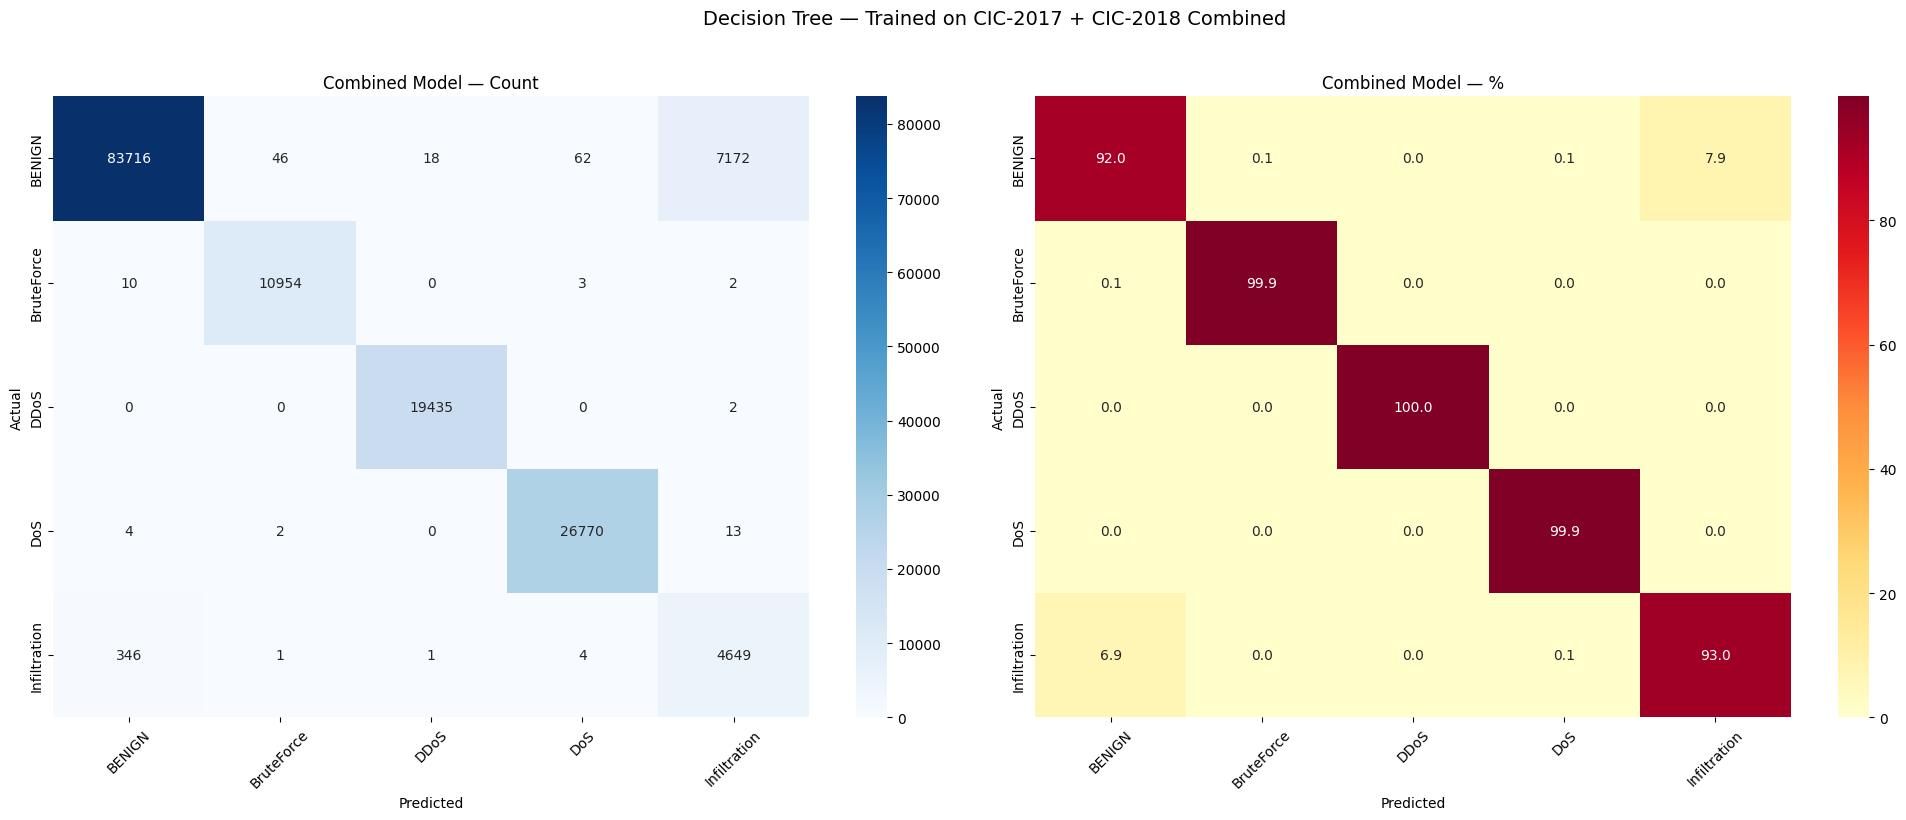

In [25]:
print(classification_report(y_comb_test, DT_combine.predict(X_comb_test),
                             target_names=le_combined.classes_, digits=4, zero_division=0))

cm_combined = confusion_matrix(y_comb_test, DT_combine.predict(X_comb_test))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_combined.classes_, yticklabels=le_combined.classes_, ax=ax1)
ax1.set_title('Combined Model — Count')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_pct = cm_combined.astype(float) / cm_combined.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le_combined.classes_, yticklabels=le_combined.classes_, ax=ax2)
ax2.set_title('Combined Model — %')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Decision Tree — Trained on CIC-2017 + CIC-2018 Combined', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
